# St. Louis Tree Canopy & Income Equity Analysis

This notebook analyzes the relationship between median household income and tree canopy coverage across census tracts in St. Louis City, Missouri. The goal is to identify **priority zones** (tracts with both low income and low canopy coverage) to help guide community-led planting initiatives.

St. Louis is one of the most well-documented examples of redlining in the US. Because trees take decades to grow, neighborhoods that experienced systematic disinvestment in the mid-20th century often still show lower canopy coverage today. This analysis asks whether that pattern is visible in current data.

## 1. Environment Setup

Import all required libraries and load environment variables. The NHGIS API key is stored as an environment variable (`IPUMS_API_KEY`) rather than hardcoded for security.

In [90]:
# Import statements and environment variables
from ipumspy import AggregateDataExtract, NhgisDataset, IpumsApiClient
from rasterio.mask import mask as geom_mask
from rasterio.plot import show
from scipy.stats import spearmanr
from shapely.geometry import mapping
import zipfile
import geopandas as gpd
import rasterstats
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
import os 
import pandas as pd
import pygris

IPUMS_API_KEY = os.getenv('IPUMS_API_KEY') # Need to configure IPUMS API KEY in environmental variables prior to running
ipums = IpumsApiClient(IPUMS_API_KEY)

#Create data/raw directories
target_dir = os.path.join("data", "raw")
os.makedirs(target_dir, exist_ok=True)

## 2. Fetch Census Tract Data via NHGIS API

We use `ipumspy` to pull tract-level median household income (ACS Table B19013) for St. Louis City, Missouri.

**Geographic identifiers:**
- State FIPS: `29` (Missouri). Using '290' for the API
- County FIPS: `510` (St. Louis City — a county-equivalent independent city, separate from St. Louis County which is FIPS 189)

**Dataset:** `2020_2024_ACS5a` (2020–2024 ACS 5-Year Estimates, Block Groups & Larger Areas)

The extract is submitted programmatically so this analysis is fully reproducible.

In [ ]:
# NHGIS dataset parameters
dataset = NhgisDataset(
    name="2020_2024_ACS5a",
    data_tables=["B19013"],
    geog_levels=["tract"]
)
# IPUMS Extract parameters, including NHGIS dataset params
extract = AggregateDataExtract(
    collection="nhgis",
    description="2024 Median Household Income by Census Tract for Missouri",
    datasets=[dataset],
    geographic_extents=['290']
    )

# Submitting and downloading the extract
ipums.submit_extract(extract)
print("Extract submitted to IPUMS.")
ipums.wait_for_extract(extract)
print("Please wait. Extract download in progress...")
ipums.download_extract(extract, download_dir=target_dir)
print(f"Extract completed! ZIP file(s) saved to {target_dir}")


In [18]:
# Extract data from zip file
zip_path = r"data\raw\nhgis0004_csv.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(target_dir)
    print(f"Unzipped files to: {target_dir}")

csv_path = r"data\raw\nhgis0004_csv\nhgis0004_ds272_20245_tract.csv"


Unzipped files to: data\raw


In [19]:
census_df = pd.read_csv(csv_path)

## 3. Load and Filter Census Tract Geometries

Use 'pygris' library to pull census tract boundaries from US Census bureau's website. Loads into gdf automatically.

For any area calculations we reproject to a metric CRS. Missouri State Plane East (EPSG 26996) is appropriate for St. Louis.

Using FIPS code '29' for input 'MO'
Using FIPS code '510' for input 'St. Louis City'
The CRS is: EPSG:4269
There are 104 tracts in this dataset


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,29,510,123200,29510123200,1232,Census Tract 1232,G5020,S,1113329,0,+38.6132904,-090.2137501,"POLYGON ((-90.22163 38.6116, -90.22153 38.6120..."
1,29,510,124600,29510124600,1246,Census Tract 1246,G5020,S,2152098,578571,+38.5890298,-090.2141395,"POLYGON ((-90.22765 38.58271, -90.22753 38.583..."
2,29,510,125500,29510125500,1255,Census Tract 1255,G5020,S,1099352,0,+38.6293098,-090.2029461,"POLYGON ((-90.21128 38.62764, -90.21126 38.627..."
165,29,510,104500,29510104500,1045,Census Tract 1045,G5020,S,1939714,0,+38.6265570,-090.2808684,"POLYGON ((-90.29432 38.62098, -90.29425 38.621..."
166,29,510,106100,29510106100,1061,Census Tract 1061,G5020,S,962329,0,+38.6693968,-090.2811551,"POLYGON ((-90.29005 38.67058, -90.28941 38.671..."


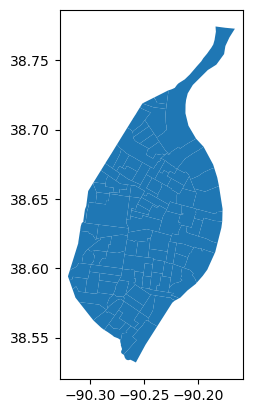

In [60]:
# Pulling St. Louis, Missouri Census Tract boundaries using pygris
stl_tracts = pygris.tracts(state = "MO", county = "St. Louis City", year=2020)

# Data checks
stl_tracts.plot() # For visual verification
print(f"The CRS is: {stl_tracts.crs}")
print(f"There are {len(stl_tracts)} tracts in this dataset")
stl_tracts.head()

In [61]:
# Obtaining sample values from each column and check data types
df_sample_val = census_df["TL_GEO_ID"].iloc[0]
gdf_sample_val = stl_tracts['GEOID'].iloc[0]
print(census_df.dtypes['TL_GEO_ID'])
print(stl_tracts.dtypes['GEOID'])
print(df_sample_val)
print(gdf_sample_val)

# Convert 'TL_GEO_ID' from INT to STR in order to join the data
census_df['TL_GEO_ID'] = census_df['TL_GEO_ID'].astype(str)

# Confirm both fields are of type 'object' or str
print(census_df.dtypes['TL_GEO_ID'])
print(stl_tracts.dtypes['GEOID'])

object
object
29001950100
29510123200
object
object


In [62]:
# Merging STL Tracts to Census data
stl_tracts_merged = stl_tracts.merge(census_df, left_on='GEOID', right_on='TL_GEO_ID', how='inner')

# Preliminary checks on merged data
print(stl_tracts_merged.shape)

if 'geometry' in stl_tracts_merged.columns: # Ensure geometry column survived the join
    print("Geometry column exists.")

stl_tracts.columns.tolist()


(104, 55)
Geometry column exists.


['STATEFP',
 'COUNTYFP',
 'TRACTCE',
 'GEOID',
 'NAME',
 'NAMELSAD',
 'MTFCC',
 'FUNCSTAT',
 'ALAND',
 'AWATER',
 'INTPTLAT',
 'INTPTLON',
 'geometry']

In [63]:
# Merged data cleanup tasks
stl_tracts_merged = stl_tracts_merged.rename(columns = {'AURUE001': 'median_income'})

# Remove blank and unnecessary columns
stl_tracts_merged = stl_tracts_merged.drop(columns=[
    # NHGIS contextual columns
    'NAME_M', 'AURUM001', 'BTTRA', 'BTBGA', 'BLKGRPA', 'CONCITA',
    'AIANHHA', 'RES_ONLYA', 'TRUSTA', 'AIHHTLI', 'AITSA', 'ANRCA',
    'CBSAA', 'CSAA', 'METDIVA', 'UAA', 'CDCURRA', 'SLDUA', 'SLDLA',
    'ZCTA5A', 'SUBMCDA', 'SDELMA', 'SDSECA', 'SDUNIA', 'PCI', 'PUMAA',
    'REGIONA', 'DIVISIONA', 'COUNTYA', 'COUSUBA', 'PLACEA', 'GISJOIN',
    'STATEA', 'TRACTA', 'GEO_ID','TL_GEO_ID','STATE','COUNTY','YEAR',
    'NAMELSAD', 'NAME_E', 'STUSAB',
    # TIGER/Line administrative columns
    'TRACTCE', 'MTFCC', 'FUNCSTAT'
])


In [68]:
# Final merged dataframe column list.
print(stl_tracts_merged.columns.to_list())

# Obtain bounds for NLCD Tree Canopy Raster Download
print(stl_tracts_merged.total_bounds)

['STATEFP', 'COUNTYFP', 'GEOID', 'NAME', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'median_income']
[-90.320515  38.532012 -90.166271  38.774368]


## 4. Load and Clip NLCD Tree Canopy Raster

The NLCD tree canopy cover raster is a national dataset at 30-meter resolution. To save memory and processing time, we clip it to the bounding box of our St. Louis City tracts before doing anything else.

We do **not** reproject the raster. Reprojecting a raster requires resampling pixel values, which introduces distortion. Instead, we let `rasterstats` handle CRS alignment internally during the zonal statistics step, keeping our pixel values untouched.

In [86]:
# Raster load and clip to bounding box goes here
nlcd_raster_raw = r'data\raw\NLCD_44d6a22a-40bc-4e66-b81b-ae412170fde0\nlcd_tcc_conus_wgs84_v2023-5_20230101_20231231_44d6a22a-40bc-4e66-b81b-ae412170fde0.tiff'

with rasterio.open(nlcd_raster_raw) as src:
    
    #1. Find CRS
    raster_crs = src.crs

    #2. Find the pixel data type
    raster_dtype = src.dtypes[0]

    #3. Find the nodata value
    raster_nodata = src.nodata

    #4. Find raster shape and bounds
    raster_shape = src.shape
    raster_bounds = src.bounds

    print(f"CRS: {raster_crs}")
    print(f"Data Type: {raster_dtype}")
    print(f"NoData Value: {raster_nodata}")
    print(f"Shape: {raster_shape}")
    print(f"Bounds: {raster_bounds}")

    # Reproject tract geometries to that of the raster
    stl_tracts_albers = stl_tracts_merged.to_crs(src.crs)


# Get the geometry shapes needed for geom_mask
shapes = [mapping(geom) for geom in stl_tracts_albers.geometry]

# Open raster, and clip to the bounding box of reprojected tracts
with rasterio.open(nlcd_raster_raw) as src:
    clipped_array, clipped_transform = geom_mask(dataset=src, shapes=shapes, nodata=255, crop=True)
    metadata = src.meta.copy()

# Update metadata with new shape and transform
metadata.update({
    "height": clipped_array.shape[1],
    "width": clipped_array.shape[2],
    "transform": clipped_transform,
    "nodata": 255
})
 
# Save clipped raster
output_path =  r'data\raw\clipped_stl_nlcd.tiff'
with rasterio.open(output_path, 'w', **metadata) as dst:
    dst.write(clipped_array)

CRS: PROJCS["Albers_Conical_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Data Type: uint8
NoData Value: 255.0
Shape: (954, 542)
Bounds: BoundingBox(left=487785.0, bottom=1736625.0, right=504045.0, top=1765245.0)


BoundingBox(left=489735.0, bottom=1737405.0, right=501795.0, top=1764945.0)
(918, 402)


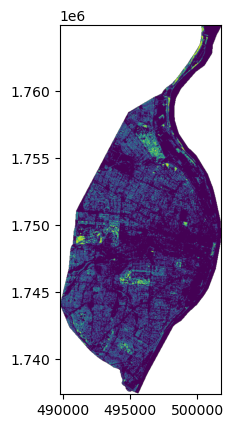

In [96]:
# Sanity checks on clipped raster
with rasterio.open(output_path) as src:
    new_raster_shape = src.shape
    new_raster_bounds = src.bounds
    print(new_raster_bounds)
    print(new_raster_shape)
    show(src)

## 5. Zonal Statistics

Calculate the mean tree canopy percentage for each census tract polygon using `rasterstats`.

**Key parameter:** `all_touched=False` — only pixels whose center falls within a tract boundary are included. Setting this to `True` would pull in boundary-straddling pixels, which in a dense urban environment with small tracts could systematically bias canopy estimates by including road and highway pixels along every tract edge.

In [ ]:
# Zonal statistics goes here

## 6. Merge and Clean

Merge the zonal statistics output with the Census income GeoDataFrame on the tract identifier. Check for nulls and any unexpected values before proceeding.

In [ ]:
# Merge and null check goes here

## 7. Exploratory Data Analysis

Before setting any thresholds, we examine the distributions of both variables and check whether a relationship between income and canopy actually exists in this data.

Steps:
- Summary statistics (min, max, mean, median) for both income and canopy
- Histogram of each variable to check distribution shape
- Scatterplot of income vs canopy (one point per tract)
- Spearman correlation coefficient

**Why Spearman?** Income distributions in urban areas tend to be right-skewed. Spearman's rank-based approach is more robust to skew and outliers than Pearson correlation.

In [ ]:
# EDA goes here

## 8. Classify Priority Zones

Based on the exploratory analysis above, set thresholds for low income and low canopy. Apply binary flags (1 = meets threshold, 0 = does not) to each tract for both variables. Priority zones are tracts where both flags equal 1.

Thresholds are documented here with the reasoning behind them.

In [ ]:
# Classification and priority zone flagging goes here

## 9. Visualization

Map the priority zones alongside income and canopy distributions. Export the final GeoDataFrame as a GeoJSON for sharing or further visualization in QGIS or Leafmap.

In [ ]:
# Visualization and export goes here